# ARC mistake iteration analyzer

`evaluate_trained_model.py` と `visualize_arc1withgen_aug_1000.ipynb` の流れを合わせて、特定の ARC 問題について推論 loop ごとの出力変化と各セルの確信度を可視化します。

In [60]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib.colors import BoundaryNorm, ListedColormap

from evaluate_trained_model import (
    apply_eval_overrides,
    load_config_from_checkpoint,
    _load_weights_only,
    _resolve_checkpoint_path,
)
from models.losses import IGNORE_LABEL_ID
from pretrain import create_dataloader, init_train_state, _get_loop_config
from puzzle_dataset import PuzzleDatasetConfig
from puzzle_full_dataset import PuzzleFullDataset

plt.rcParams["figure.dpi"] = 120

## 設定

`CHECKPOINT` と対象問題を変更してください。`SPLIT="test"` の場合は、test example に保存されている train context と query を使って評価時と同じ full-context sample を作ります。

In [ ]:
# ここを変更してください
CHECKPOINT = "checkpoints/URM-arcagi1-full-gen/step_40494.pt"  # checkpoint file or directory
DATASET_DIR = None  # None なら checkpoint の config.data_path を使う。例: Path("data/arc1withgen-aug-1000")

SPLIT = "test"       # "train" or "test"
GROUP_ID = 9          # 0-based group id
PUZZLE_ID = 0         # group 内 local puzzle id。PUZZLE_ID_MODE="absolute" なら split 全体の puzzle index
PUZZLE_ID_MODE = "local"  # "local", "absolute", or "auto"
EXAMPLE_ID = 0        # puzzle 内 local example id。EXAMPLE_ID_MODE="absolute" なら split 全体の example index
EXAMPLE_ID_MODE = "local"  # "local", "absolute", "auto", or "random"
RANDOM_SEED = 0       # EXAMPLE_ID_MODE="random" のときだけ使う

BATCH_SIZE = 1
LOOPS_TO_RUN = 32
LOOPS_TO_SHOW = list(range(1, 9)) + [16, 24, 32]
HIDDEN_DIFF_THRESHOLD = None

# train split で full-context sample を作るとき、対象 example 以外に同じ puzzle から何個 context を入れるか
TRAIN_CONTEXT_COUNT = 3

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


In [62]:
ARC_TOKEN_PAD = 0
ARC_TOKEN_EOS = 1
ARC_TOKEN_COLOR_OFFSET = 2
ARC_NUM_TOKENS = 12

ARC_TOKEN_COLORS = [
    "#2D257F",  # token 0: PAD
    "#E6E6E6",  # token 1: <eos>
    "#000000",  # token 2: ARC color 0
    "#0074D9",  # token 3: ARC color 1 blue
    "#FF4136",  # token 4: ARC color 2 red
    "#2ECC40",  # token 5: ARC color 3 green
    "#FFDC00",  # token 6: ARC color 4 yellow
    "#AAAAAA",  # token 7: ARC color 5 gray
    "#F012BE",  # token 8: ARC color 6 magenta
    "#FF851B",  # token 9: ARC color 7 orange
    "#7FDBFF",  # token 10: ARC color 8 cyan
    "#870C25",  # token 11: ARC color 9 dark red
]
ARC_CMAP = ListedColormap(ARC_TOKEN_COLORS)
ARC_NORM = BoundaryNorm(np.arange(-0.5, ARC_NUM_TOKENS + 0.5, 1.0), ARC_CMAP.N)


def decode_arc_canvas(tokens, shape):
    canvas = np.asarray(tokens, dtype=np.uint8).reshape(tuple(int(x) for x in shape))
    nonzero_rows = np.flatnonzero(np.any(canvas != ARC_TOKEN_PAD, axis=1))
    nonzero_cols = np.flatnonzero(np.any(canvas != ARC_TOKEN_PAD, axis=0))
    if nonzero_rows.size == 0 or nonzero_cols.size == 0:
        return np.zeros((1, 1), dtype=np.uint8)
    active = canvas[: int(nonzero_rows[-1]) + 1, : int(nonzero_cols[-1]) + 1]
    eos_rows = np.flatnonzero(np.any(active == ARC_TOKEN_EOS, axis=1) & ~np.any(active >= ARC_TOKEN_COLOR_OFFSET, axis=1))
    eos_cols = np.flatnonzero(np.any(active == ARC_TOKEN_EOS, axis=0) & ~np.any(active >= ARC_TOKEN_COLOR_OFFSET, axis=0))
    grid_h = int(eos_rows[0]) if eos_rows.size else active.shape[0]
    grid_w = int(eos_cols[0]) if eos_cols.size else active.shape[1]
    cropped = active[:grid_h, :grid_w]
    if cropped.size == 0:
        return np.zeros((1, 1), dtype=np.uint8)
    return cropped.astype(np.uint8)


def render_grid(ax, grid, title, wrong_mask=None, changed_mask=None):
    grid = np.asarray(grid)
    ax.imshow(grid, cmap=ARC_CMAP, norm=ARC_NORM, interpolation="nearest")
    ax.set_title(f"{title}\n{grid.shape[0]}x{grid.shape[1]}", fontsize=10)
    ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
    ax.grid(which="minor", color="#222222", linewidth=0.45)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.set_aspect("equal")
    for spine in ax.spines.values():
        spine.set_color("#666666")
        spine.set_linewidth(1.0)
    if wrong_mask is not None:
        ys, xs = np.where(wrong_mask)
        ax.scatter(xs, ys, marker="x", s=80, linewidths=1.6, color="white")
        ax.scatter(xs, ys, marker="x", s=45, linewidths=1.2, color="#D62728")
    if changed_mask is not None:
        ys, xs = np.where(changed_mask)
        ax.scatter(xs, ys, marker="o", s=55, facecolors="none", edgecolors="#00FFFF", linewidths=1.5)


def render_confidence(ax, confidence, title):
    confidence = np.asarray(confidence, dtype=float)
    image = ax.imshow(confidence, cmap="viridis", vmin=0.0, vmax=1.0, interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xticks(np.arange(-0.5, confidence.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, confidence.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.35, alpha=0.45)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.set_aspect("equal")
    return image

In [63]:
def load_split_arrays(dataset_dir: Path, split: str):
    split_dir = dataset_dir / split
    with (split_dir / "dataset.json").open() as f:
        metadata = json.load(f)
    data = {
        "split": split,
        "metadata": metadata,
        "inputs": np.load(split_dir / "all__inputs.npy", mmap_mode="r"),
        "labels": np.load(split_dir / "all__labels.npy", mmap_mode="r"),
        "seq_offsets": np.load(split_dir / "all__seq_offsets.npy"),
        "label_seq_offsets": np.load(split_dir / "all__label_seq_offsets.npy"),
        "seq_shapes": np.load(split_dir / "all__seq_shapes.npy"),
        "label_seq_shapes": np.load(split_dir / "all__label_seq_shapes.npy"),
        "puzzle_indices": np.load(split_dir / "all__puzzle_indices.npy"),
        "group_indices": np.load(split_dir / "all__group_indices.npy"),
        "puzzle_identifiers": np.load(split_dir / "all__puzzle_identifiers.npy"),
    }
    examples_path = split_dir / "all__examples.npy"
    example_shapes_path = split_dir / "all__example_shapes.npy"
    if examples_path.exists() and example_shapes_path.exists():
        data["examples"] = np.load(examples_path, allow_pickle=True)
        data["example_shapes"] = np.load(example_shapes_path, allow_pickle=True)
    return data


def resolve_puzzle_index(split_data, group_id, puzzle_id, mode="local"):
    group_indices = split_data["group_indices"]
    if not (0 <= group_id < len(group_indices) - 1):
        raise IndexError(f"GROUP_ID={group_id} is out of range [0, {len(group_indices) - 2}]")
    group_start = int(group_indices[group_id])
    group_end = int(group_indices[group_id + 1])
    group_size = group_end - group_start
    if mode == "local":
        if not (0 <= puzzle_id < group_size):
            raise IndexError(f"local PUZZLE_ID={puzzle_id} is out of range [0, {group_size - 1}] for group {group_id}")
        return group_start + int(puzzle_id)
    if mode == "absolute":
        if not (group_start <= puzzle_id < group_end):
            raise IndexError(f"absolute PUZZLE_ID={puzzle_id} is not in group {group_id}; valid [{group_start}, {group_end - 1}]")
        return int(puzzle_id)
    if mode == "auto":
        if group_start <= puzzle_id < group_end:
            return int(puzzle_id)
        if 0 <= puzzle_id < group_size:
            return group_start + int(puzzle_id)
    raise ValueError('PUZZLE_ID_MODE must be "local", "absolute", or "auto"')


def resolve_example_index(split_data, puzzle_index, example_id, mode="local", seed=None):
    start = int(split_data["puzzle_indices"][puzzle_index])
    end = int(split_data["puzzle_indices"][puzzle_index + 1])
    if start >= end:
        raise ValueError(f"puzzle_index={puzzle_index} has no examples")
    if mode == "random":
        return random.Random(seed).randrange(start, end)
    if mode == "local":
        if not (0 <= example_id < end - start):
            raise IndexError(f"local EXAMPLE_ID={example_id} is out of range [0, {end - start - 1}]")
        return start + int(example_id)
    if mode == "absolute":
        if not (start <= example_id < end):
            raise IndexError(f"absolute EXAMPLE_ID={example_id} is not in puzzle; valid [{start}, {end - 1}]")
        return int(example_id)
    if mode == "auto":
        if start <= example_id < end:
            return int(example_id)
        if 0 <= example_id < end - start:
            return start + int(example_id)
    raise ValueError('EXAMPLE_ID_MODE must be "local", "absolute", "auto", or "random"')


def identifier_name(dataset_dir: Path, split_data, puzzle_index):
    with (dataset_dir / "identifiers.json").open() as f:
        identifiers = json.load(f)
    ident = int(split_data["puzzle_identifiers"][puzzle_index])
    return identifiers[ident] if 0 <= ident < len(identifiers) else f"<unknown:{ident}>"


def load_example_pair(split_data, example_index):
    in_start = int(split_data["seq_offsets"][example_index])
    in_end = int(split_data["seq_offsets"][example_index + 1])
    label_start = int(split_data["label_seq_offsets"][example_index])
    label_end = int(split_data["label_seq_offsets"][example_index + 1])
    input_shape = split_data["seq_shapes"][example_index]
    output_shape = split_data["label_seq_shapes"][example_index]
    input_grid = decode_arc_canvas(split_data["inputs"][in_start:in_end], input_shape)
    output_grid = decode_arc_canvas(split_data["labels"][label_start:label_end], output_shape)
    return input_grid, output_grid


def load_context_pairs_if_available(split_data, example_index):
    if "examples" not in split_data:
        return []
    context = split_data["examples"][example_index]
    context_shapes = split_data["example_shapes"][example_index]
    pairs = []
    for i in range(len(context)):
        inp = decode_arc_canvas(context[i][0], context_shapes[i][0])
        out = decode_arc_canvas(context[i][1], context_shapes[i][1])
        pairs.append((inp, out))
    return pairs

In [64]:
resolved_checkpoint = _resolve_checkpoint_path(CHECKPOINT)
if resolved_checkpoint is None:
    raise FileNotFoundError(f"Could not resolve checkpoint path from: {CHECKPOINT}")
checkpoint_path = Path(resolved_checkpoint)

config = load_config_from_checkpoint(str(checkpoint_path))
apply_eval_overrides(
    config,
    batch_size=BATCH_SIZE,
    loops=LOOPS_TO_RUN,
    hidden_diff_threshold=HIDDEN_DIFF_THRESHOLD,
)
config.checkpoint_path = str(checkpoint_path.parent)
dataset_dir = Path(config.data_path if DATASET_DIR is None else DATASET_DIR)
config.data_path = str(dataset_dir)

print("checkpoint:", checkpoint_path)
print("dataset:", dataset_dir)
print("mask_full_training:", config.mask_full_training)
print("loops_to_run:", LOOPS_TO_RUN)

checkpoint: checkpoints/URM-arcagi1-full-gen/step_40494.pt
dataset: data/arc1withgen-aug-1000
mask_full_training: True
loops_to_run: 32


split: test
group_id: 8  puzzle range: [8000, 8999]  group size: 1000
puzzle_index: 8000  local puzzle id: 0
puzzle identifier: df8cc377
example_index: 10000  local example id: 0 / 0


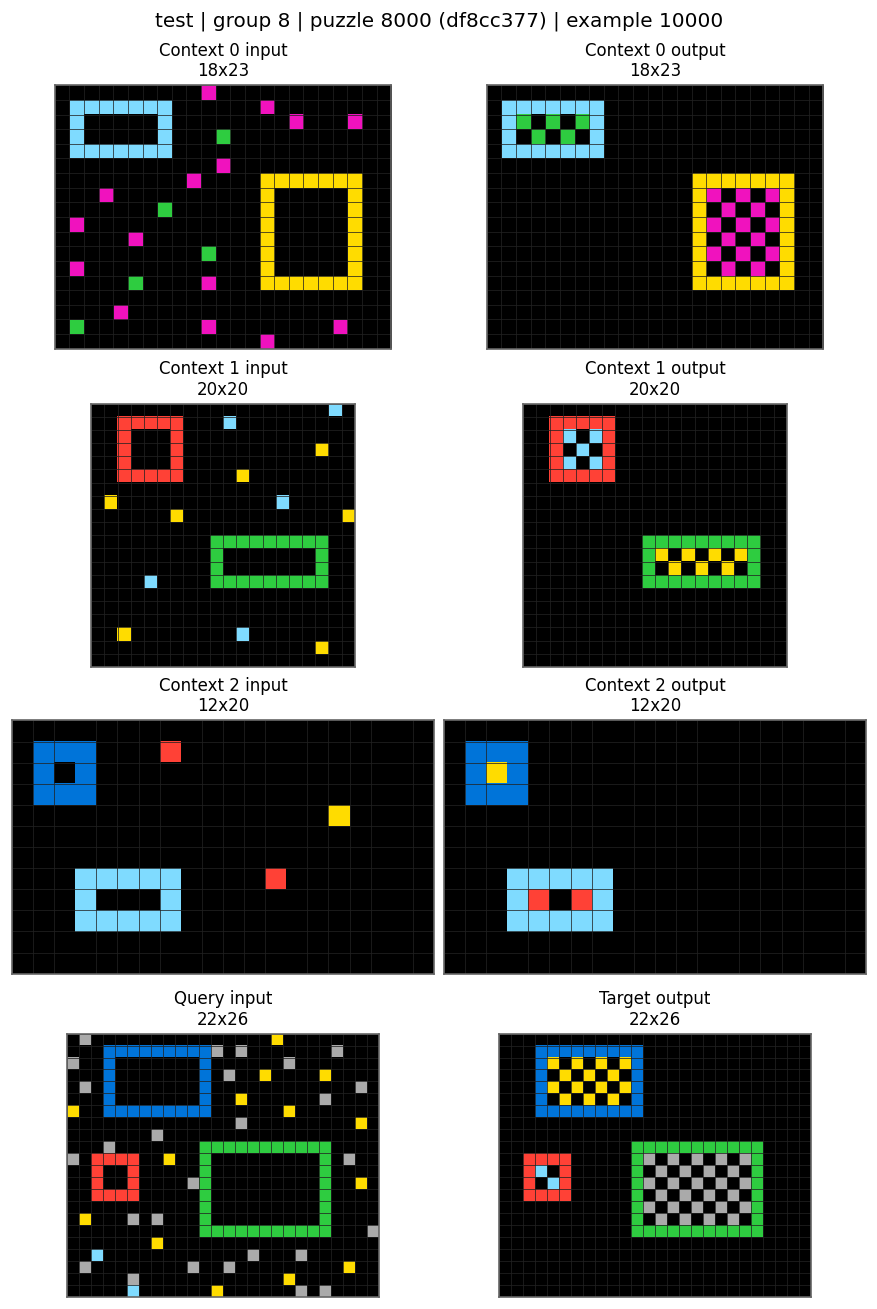

In [65]:
split_data = load_split_arrays(dataset_dir, SPLIT)
puzzle_index = resolve_puzzle_index(split_data, GROUP_ID, PUZZLE_ID, PUZZLE_ID_MODE)
example_index = resolve_example_index(split_data, puzzle_index, EXAMPLE_ID, EXAMPLE_ID_MODE, RANDOM_SEED)

group_start = int(split_data["group_indices"][GROUP_ID])
group_end = int(split_data["group_indices"][GROUP_ID + 1])
puzzle_start = int(split_data["puzzle_indices"][puzzle_index])
puzzle_end = int(split_data["puzzle_indices"][puzzle_index + 1])
name = identifier_name(dataset_dir, split_data, puzzle_index)

print(f"split: {SPLIT}")
print(f"group_id: {GROUP_ID}  puzzle range: [{group_start}, {group_end - 1}]  group size: {group_end - group_start}")
print(f"puzzle_index: {puzzle_index}  local puzzle id: {puzzle_index - group_start}")
print(f"puzzle identifier: {name}")
print(f"example_index: {example_index}  local example id: {example_index - puzzle_start} / {puzzle_end - puzzle_start - 1}")

context_pairs = load_context_pairs_if_available(split_data, example_index)
target_input, target_output = load_example_pair(split_data, example_index)

rows = len(context_pairs) + 1
fig, axes = plt.subplots(rows, 2, figsize=(7.2, max(3.0, 2.7 * rows)), squeeze=False, constrained_layout=True)
for row, (inp, out) in enumerate(context_pairs):
    render_grid(axes[row, 0], inp, f"Context {row} input")
    render_grid(axes[row, 1], out, f"Context {row} output")
render_grid(axes[-1, 0], target_input, "Query input")
render_grid(axes[-1, 1], target_output, "Target output")
fig.suptitle(f"{SPLIT} | group {GROUP_ID} | puzzle {puzzle_index} ({name}) | example {example_index}", fontsize=12)
plt.show()

In [66]:
def make_full_dataset(config, split):
    ds = PuzzleFullDataset(
        PuzzleDatasetConfig(
            seed=config.seed,
            dataset_path=config.data_path,
            global_batch_size=1,
            test_set_mode=(split == "test"),
            epochs_per_iter=1,
            grad_accum_steps=1,
            rank=0,
            num_replicas=1,
            data_fraction=1.0,
            examples_per_puzzle=config.examples_per_puzzle,
            online_aug=None,
            masked_input=config.masked_input,
            arc_output_mask=None,
            full_min_pairs=config.full_min_pairs,
            full_max_pairs=config.full_max_pairs,
        ),
        split=split,
    )
    ds._lazy_load_dataset()
    return ds


def build_single_full_batch(ds, split_data, puzzle_index, example_index):
    dataset = ds._data["all"]
    if ds.split == "test":
        sample = ds._build_test_sample(dataset, int(example_index))
    else:
        start = int(split_data["puzzle_indices"][puzzle_index])
        end = int(split_data["puzzle_indices"][puzzle_index + 1])
        rng = np.random.default_rng(RANDOM_SEED)
        candidates = [i for i in range(start, end) if i != example_index]
        if len(candidates) < TRAIN_CONTEXT_COUNT:
            chosen_context = candidates
        else:
            chosen_context = rng.choice(candidates, size=TRAIN_CONTEXT_COUNT, replace=False).tolist()
        selected = np.array(chosen_context + [int(example_index)], dtype=np.int64)
        sample = ds._build_full_sample(dataset, selected, rng, target_pair_index=len(selected) - 1)

    puzzle_identifier = np.array([int(split_data["puzzle_identifiers"][puzzle_index])], dtype=np.int64)
    return ds._collate_built_samples([sample], puzzle_identifier)


full_ds = make_full_dataset(config, SPLIT)
batch_cpu = build_single_full_batch(full_ds, split_data, puzzle_index, example_index)
print({k: tuple(v.shape) for k, v in batch_cpu.items()})

{'inputs': (3582,), 'labels': (3582,), 'answer_mask': (3582,), 'source_inputs': (3582,), 'position_ids': (3582, 4), 'seq_lengths': (1,), 'puzzle_identifiers': (1,), 'arc_identifiers': (1,), 'seq_offsets': (2,)}


In [67]:
if DEVICE != "cuda":
    raise RuntimeError("この notebook は evaluate_trained_model.py と同じく CUDA 前提です。CUDA 環境で実行してください。")

torch.random.manual_seed(config.seed)
train_loader, train_metadata = create_dataloader(
    config,
    "train",
    test_set_mode=False,
    epochs_per_iter=1,
    global_batch_size=1,
    rank=0,
    world_size=1,
)
train_state = init_train_state(config, train_metadata, rank=0, world_size=1)
_load_weights_only(train_state, config, checkpoint_path)
train_state.model.eval()

loop_config = _get_loop_config(train_state.model)
if loop_config is not None:
    loop_config.loops = LOOPS_TO_RUN
    if HIDDEN_DIFF_THRESHOLD is not None:
        loop_config.norm_diff_min = HIDDEN_DIFF_THRESHOLD
        loop_config.norm_diff_max = HIDDEN_DIFF_THRESHOLD

del train_loader
print("model loaded")

Dataset train has 960 groups.
Training split uses PuzzleFullDataset with 3-8 pairs per sample.
Created dataloader for split 'train'.
torch.compile enabled (dynamic=True)
Loading checkpoint checkpoints/URM-arcagi1-full-gen/step_40494.pt
model loaded


In [68]:
def target_token_mask(batch):
    labels = batch["labels"].detach().cpu().numpy()
    positions = batch["position_ids"].detach().cpu().numpy()
    mask = labels != IGNORE_LABEL_ID
    if not np.any(mask):
        raise ValueError("No target tokens found in labels")
    target_pair_id = int(positions[mask][0, 0])
    return mask & (positions[:, 0] == target_pair_id) & (positions[:, 1] == 1)


def positioned_grid(values, positions, mask, fill=np.nan):
    rows = positions[mask, -2].astype(int)
    cols = positions[mask, -1].astype(int)
    h = int(rows.max()) + 1
    w = int(cols.max()) + 1
    dtype = float if isinstance(fill, float) and np.isnan(fill) else np.asarray(values).dtype
    grid = np.full((h, w), fill, dtype=dtype)
    vals = np.asarray(values)[mask]
    grid[rows, cols] = vals
    return grid


def crop_token_grid(grid):
    grid = np.asarray(grid)
    nonzero_rows = np.flatnonzero(np.any(grid != ARC_TOKEN_PAD, axis=1))
    nonzero_cols = np.flatnonzero(np.any(grid != ARC_TOKEN_PAD, axis=0))
    if nonzero_rows.size == 0 or nonzero_cols.size == 0:
        return np.zeros((1, 1), dtype=np.uint8)
    active = grid[: int(nonzero_rows[-1]) + 1, : int(nonzero_cols[-1]) + 1]
    eos_rows = np.flatnonzero(np.any(active == ARC_TOKEN_EOS, axis=1) & ~np.any(active >= ARC_TOKEN_COLOR_OFFSET, axis=1))
    eos_cols = np.flatnonzero(np.any(active == ARC_TOKEN_EOS, axis=0) & ~np.any(active >= ARC_TOKEN_COLOR_OFFSET, axis=0))
    grid_h = int(eos_rows[0]) if eos_rows.size else active.shape[0]
    grid_w = int(eos_cols[0]) if eos_cols.size else active.shape[1]
    cropped = active[:grid_h, :grid_w]
    if cropped.size == 0:
        return np.zeros((1, 1), dtype=np.uint8)
    return cropped.astype(np.uint8)


def batch_pair_grid(values, positions, pair_id, io_id):
    pair_mask = (positions[:, 0] == pair_id) & (positions[:, 1] == io_id)
    if not np.any(pair_mask):
        return np.zeros((1, 1), dtype=np.uint8)
    return positioned_grid(values, positions, pair_mask, fill=ARC_TOKEN_PAD).astype(np.uint8)


def reconstruct_prompt_from_batch(batch):
    inputs = batch["inputs"].detach().cpu().numpy()
    labels = batch["labels"].detach().cpu().numpy()
    positions = batch["position_ids"].detach().cpu().numpy()
    target_mask = labels != IGNORE_LABEL_ID
    if not np.any(target_mask):
        raise ValueError("No target tokens found in labels")
    target_pair_id = int(positions[target_mask][0, 0])
    pair_ids = sorted(int(x) for x in np.unique(positions[:, 0]))

    prompt_pairs = []
    for pair_id in pair_ids:
        input_grid = batch_pair_grid(inputs, positions, pair_id, 0)
        output_grid = batch_pair_grid(inputs, positions, pair_id, 1)
        prompt_pairs.append(
            {
                "pair_id": pair_id,
                "is_query": pair_id == target_pair_id,
                "input": input_grid,
                "output": output_grid,
            }
        )

    if not any(pair["is_query"] for pair in prompt_pairs):
        raise ValueError(f"Could not reconstruct query input for target_pair_id={target_pair_id}")
    return prompt_pairs, target_pair_id


def run_iteration_trace(train_state, batch_cpu, loops_to_run):
    batch = {k: v.cuda() for k, v in batch_cpu.items()}
    return_keys = {"logits", "preds", "q_halt_logits", "q_continue_logits"}
    trace = []
    with torch.inference_mode(), torch.device("cuda"):
        carry = train_state.model.initial_carry(batch)
        for step in range(1, loops_to_run + 1):
            carry, loss, metrics, preds, all_finish = train_state.model(
                carry=carry,
                batch=batch,
                return_keys=return_keys,
            )
            logits = preds["logits"].detach().float().cpu()
            probs = F.softmax(logits, dim=-1)
            confidence, pred_tokens = probs.max(dim=-1)
            true_prob = torch.gather(
                probs,
                dim=-1,
                index=torch.where(batch["labels"] == IGNORE_LABEL_ID, 0, batch["labels"]).detach().cpu().long().unsqueeze(-1),
            ).squeeze(-1)
            trace.append(
                {
                    "loop": step,
                    "pred_tokens": pred_tokens.numpy(),
                    "confidence": confidence.numpy(),
                    "true_prob": true_prob.numpy(),
                    "q_halt": preds["q_halt_logits"].detach().sigmoid().cpu().numpy(),
                    "q_continue": preds["q_continue_logits"].detach().sigmoid().cpu().numpy(),
                    "all_finish": bool(all_finish),
                }
            )
            if all_finish and step >= loops_to_run:
                break
    return trace


trace = run_iteration_trace(train_state, batch_cpu, LOOPS_TO_RUN)
print(f"collected {len(trace)} loops")

collected 32 loops


In [69]:
labels_np = batch_cpu["labels"].numpy()
positions_np = batch_cpu["position_ids"].numpy()
batch_prompt_pairs, batch_target_pair_id = reconstruct_prompt_from_batch(batch_cpu)
mask = target_token_mask(batch_cpu)
target_grid = positioned_grid(labels_np, positions_np, mask, fill=ARC_TOKEN_PAD).astype(np.uint8)

rows = []
prev_grid = None
decoded_trace = []
for item in trace:
    pred_grid = positioned_grid(item["pred_tokens"], positions_np, mask, fill=ARC_TOKEN_PAD).astype(np.int16)
    conf_grid = positioned_grid(item["confidence"], positions_np, mask, fill=np.nan)
    true_prob_grid = positioned_grid(item["true_prob"], positions_np, mask, fill=np.nan)
    wrong_mask = pred_grid != target_grid
    changed_mask = np.zeros_like(wrong_mask, dtype=bool) if prev_grid is None else pred_grid != prev_grid
    rows.append(
        {
            "loop": item["loop"],
            "exact": bool(not wrong_mask.any()),
            "cell_accuracy": float((~wrong_mask).mean()),
            "wrong_cells": int(wrong_mask.sum()),
            "changed_from_prev": int(changed_mask.sum()),
            "mean_confidence": float(np.nanmean(conf_grid)),
            "mean_true_prob": float(np.nanmean(true_prob_grid)),
            "q_halt": float(item["q_halt"][0]),
            "q_continue": float(item["q_continue"][0]),
        }
    )
    decoded_trace.append({**item, "pred_grid": pred_grid, "conf_grid": conf_grid, "true_prob_grid": true_prob_grid, "wrong_mask": wrong_mask, "changed_mask": changed_mask})
    prev_grid = pred_grid

summary_rows = rows
summary = {key: np.array([row[key] for row in summary_rows]) for key in summary_rows[0].keys()}
try:
    import pandas as pd
    display(pd.DataFrame(summary_rows))
except ImportError:
    for row in summary_rows:
        print(row)

,loop,exact,cell_accuracy,wrong_cells,changed_from_prev,mean_confidence,mean_true_prob,q_halt,q_continue
0,1,False,0.927536,45,0,0.999411,0.927070,0.006693,0.006693
1,2,False,0.929147,44,1,0.999915,0.929068,0.006693,0.006693
2,3,False,0.929147,44,0,0.998473,0.928297,0.006693,0.006693
3,4,False,0.929147,44,2,0.999122,0.928363,0.006693,0.006693
4,5,False,0.925926,46,2,0.999086,0.926387,0.006693,0.006693
5,6,False,0.929147,44,2,0.999262,0.928411,0.006693,0.006693
6,7,False,0.925926,46,2,0.998562,0.927167,0.006693,0.006693
7,8,False,0.927536,45,1,0.998693,0.927267,0.006693,0.006693
8,9,False,0.925926,46,1,0.999069,0.926521,0.006693,0.006693
9,10,False,0.927536,45,1,0.999258,0.927390,0.006693,0.006693


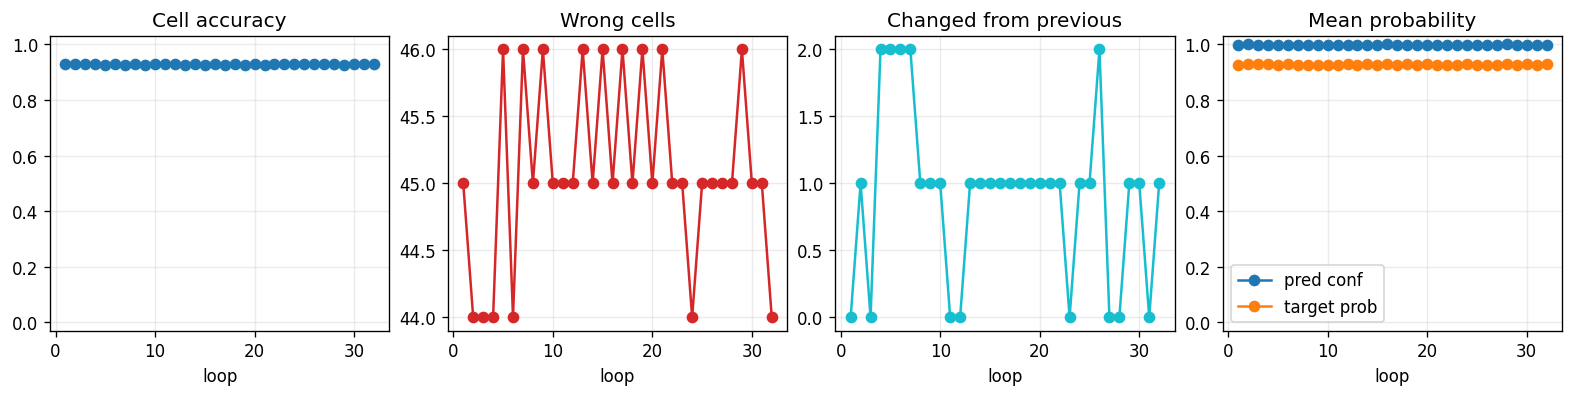

In [70]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2), constrained_layout=True)
axes[0].plot(summary["loop"], summary["cell_accuracy"], marker="o")
axes[0].set_title("Cell accuracy")
axes[0].set_xlabel("loop")
axes[0].set_ylim(-0.03, 1.03)
axes[0].grid(True, alpha=0.25)

axes[1].plot(summary["loop"], summary["wrong_cells"], marker="o", color="#D62728")
axes[1].set_title("Wrong cells")
axes[1].set_xlabel("loop")
axes[1].grid(True, alpha=0.25)

axes[2].plot(summary["loop"], summary["changed_from_prev"], marker="o", color="#17BECF")
axes[2].set_title("Changed from previous")
axes[2].set_xlabel("loop")
axes[2].grid(True, alpha=0.25)

axes[3].plot(summary["loop"], summary["mean_confidence"], marker="o", label="pred conf")
axes[3].plot(summary["loop"], summary["mean_true_prob"], marker="o", label="target prob")
axes[3].set_title("Mean probability")
axes[3].set_xlabel("loop")
axes[3].set_ylim(-0.03, 1.03)
axes[3].legend()
axes[3].grid(True, alpha=0.25)
plt.show()

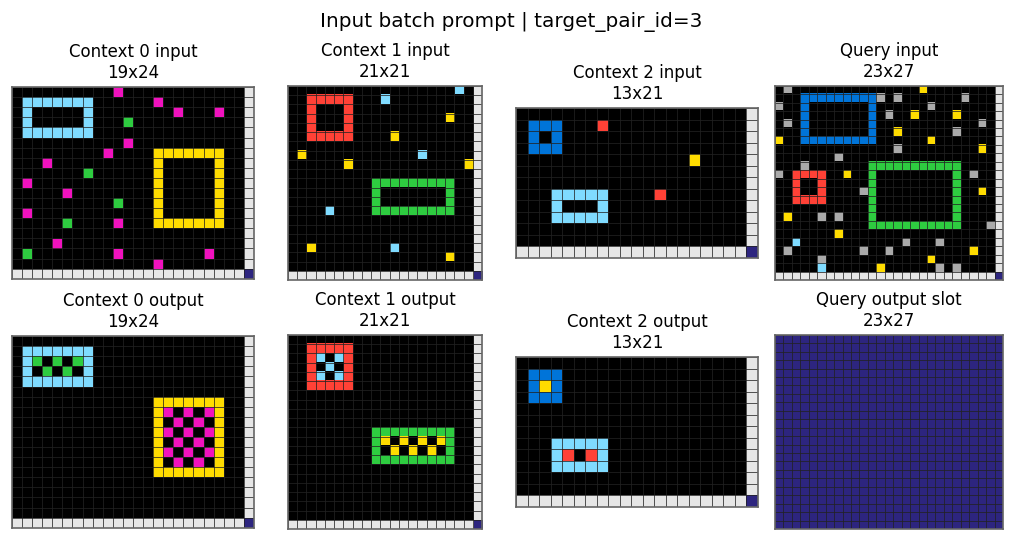

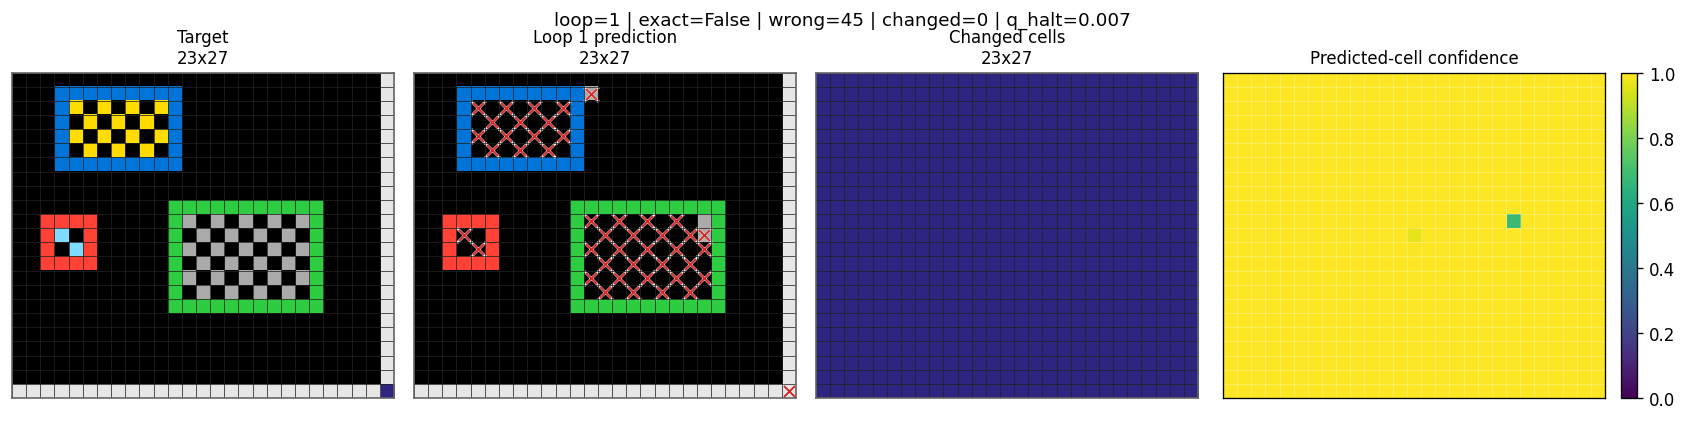

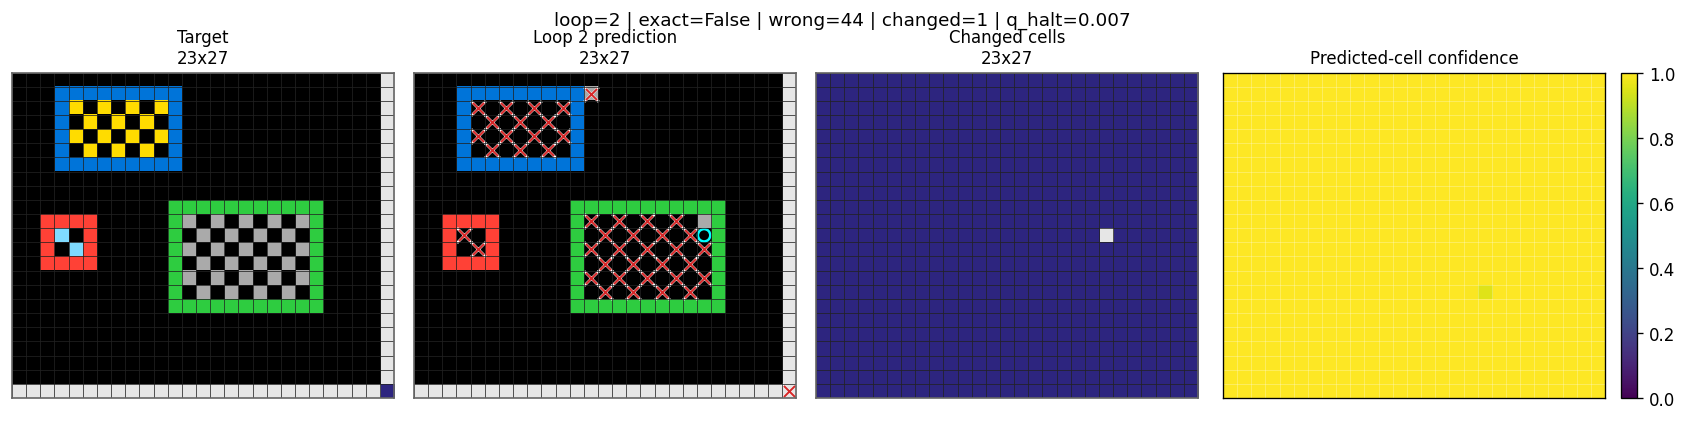

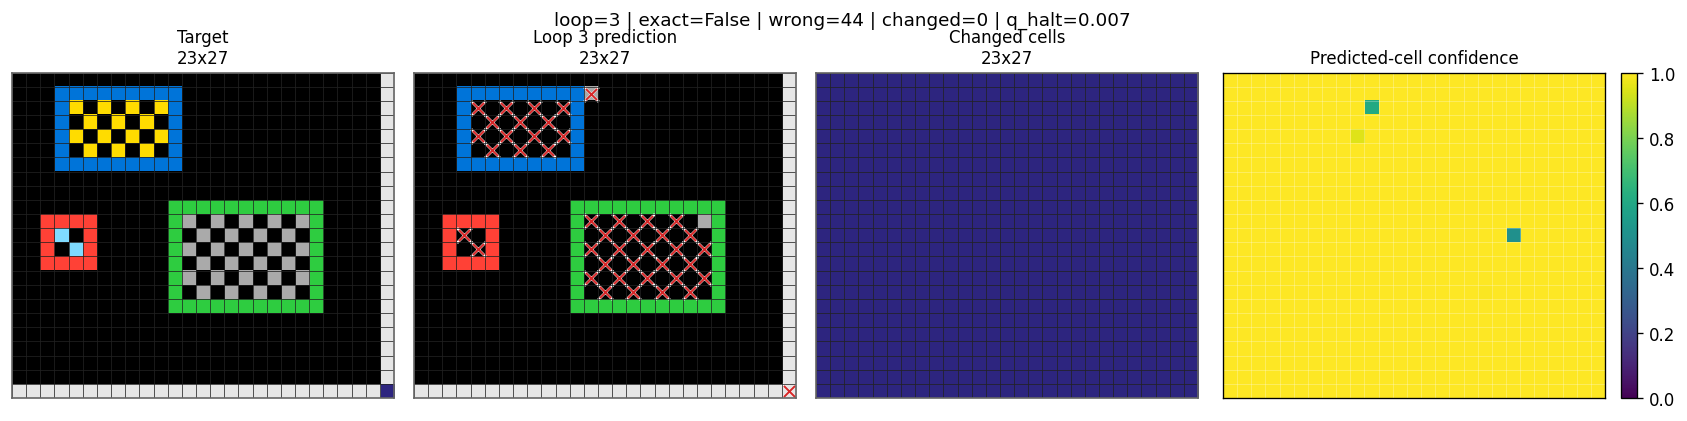

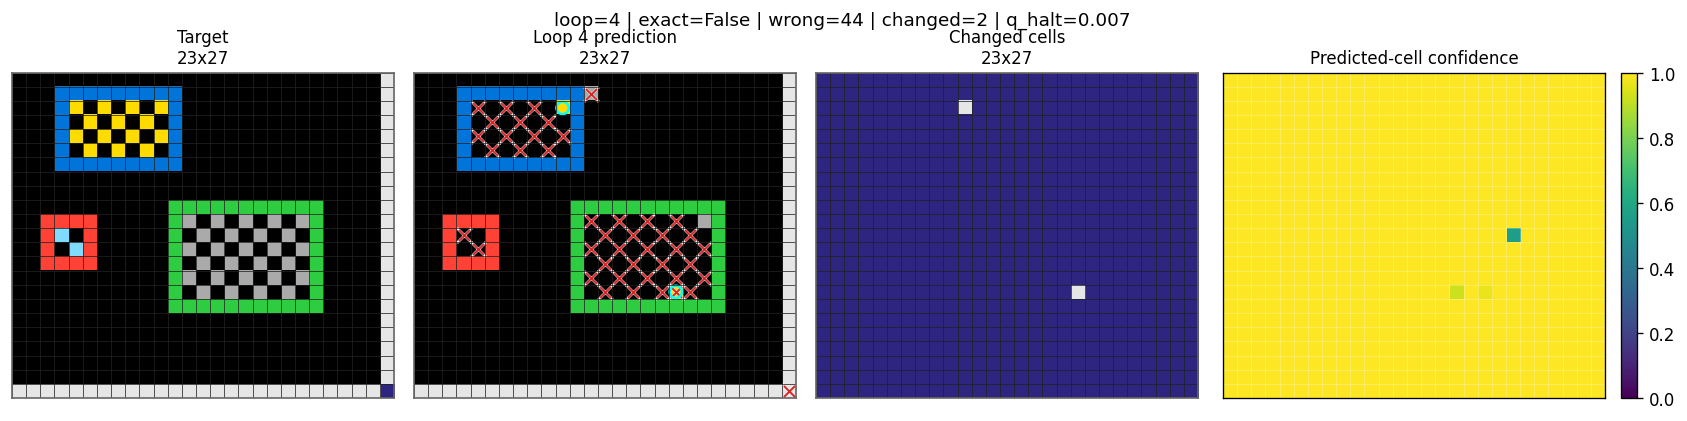

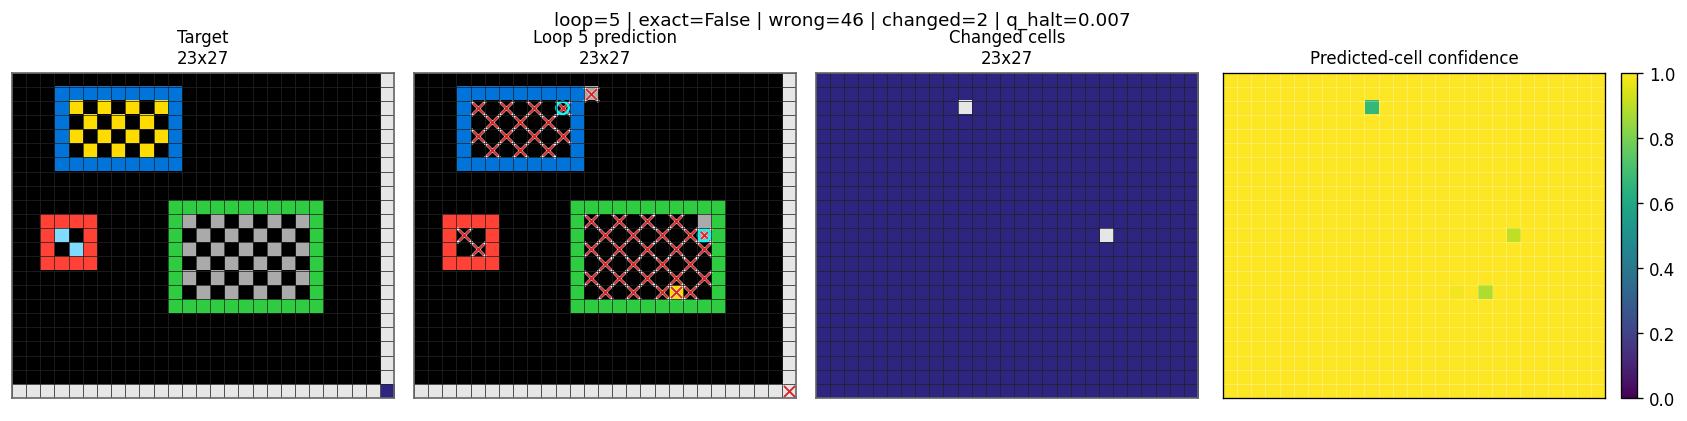

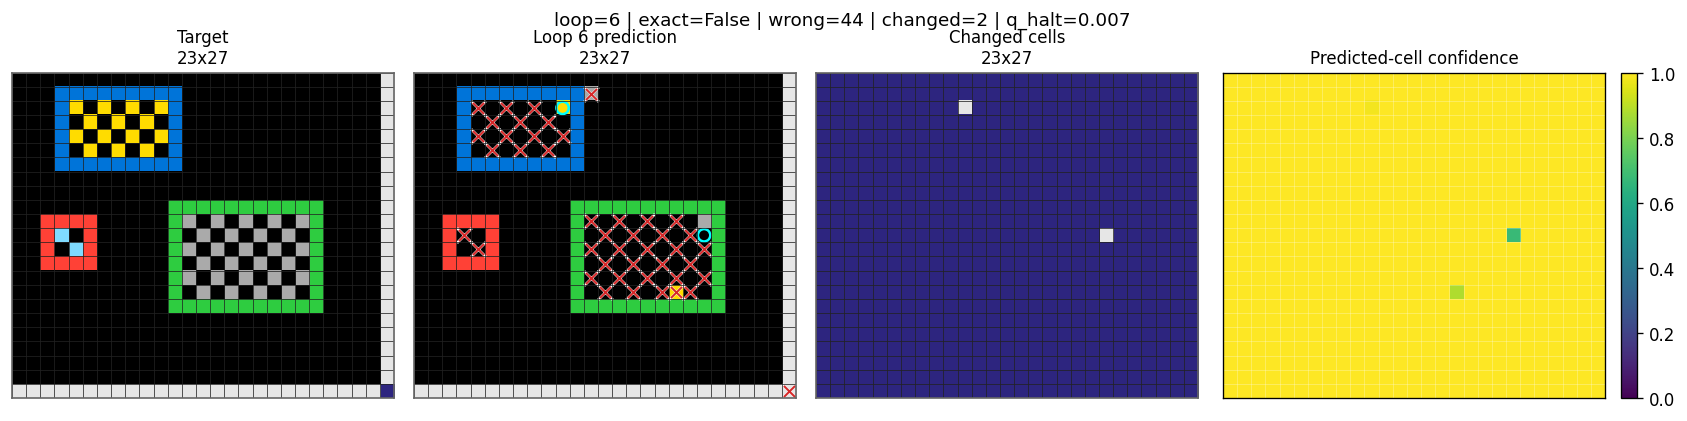

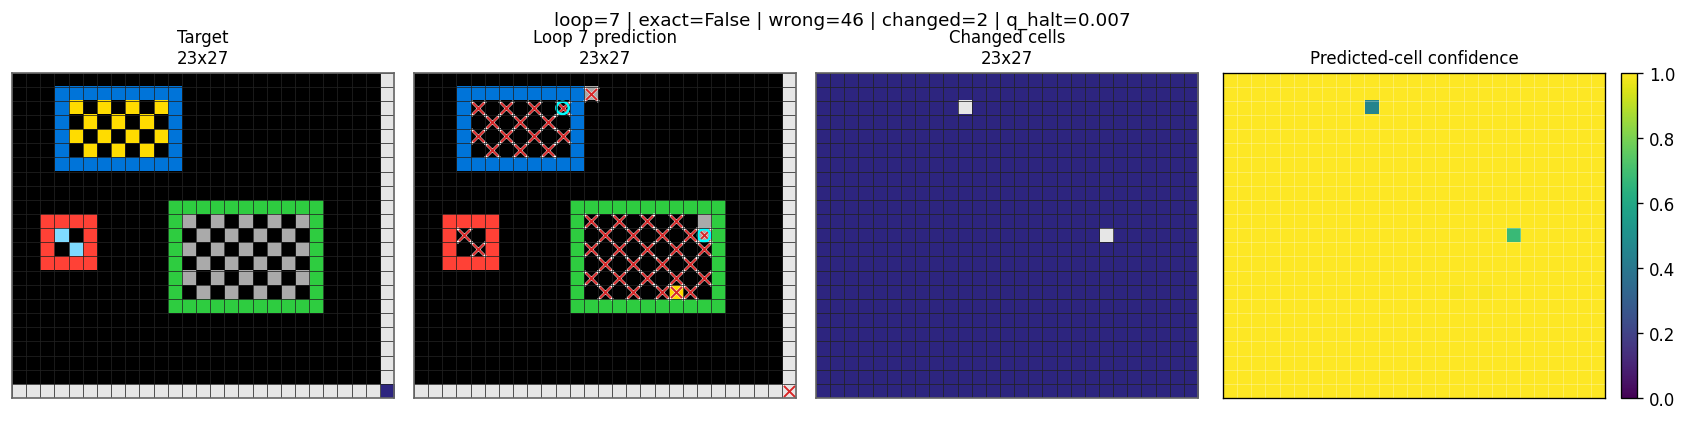

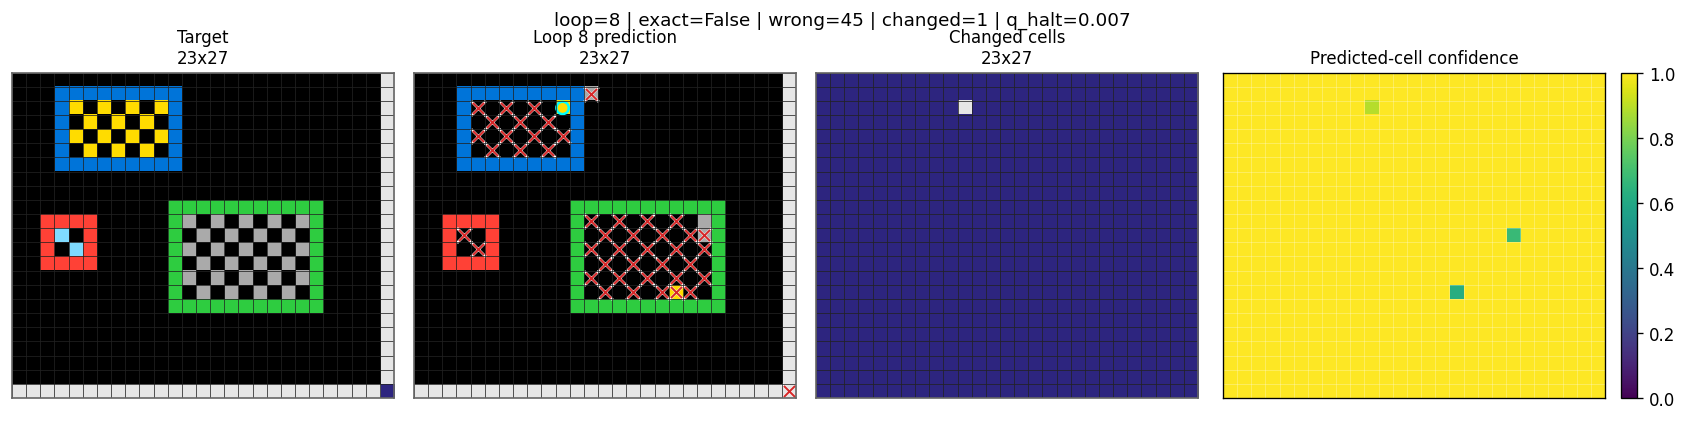

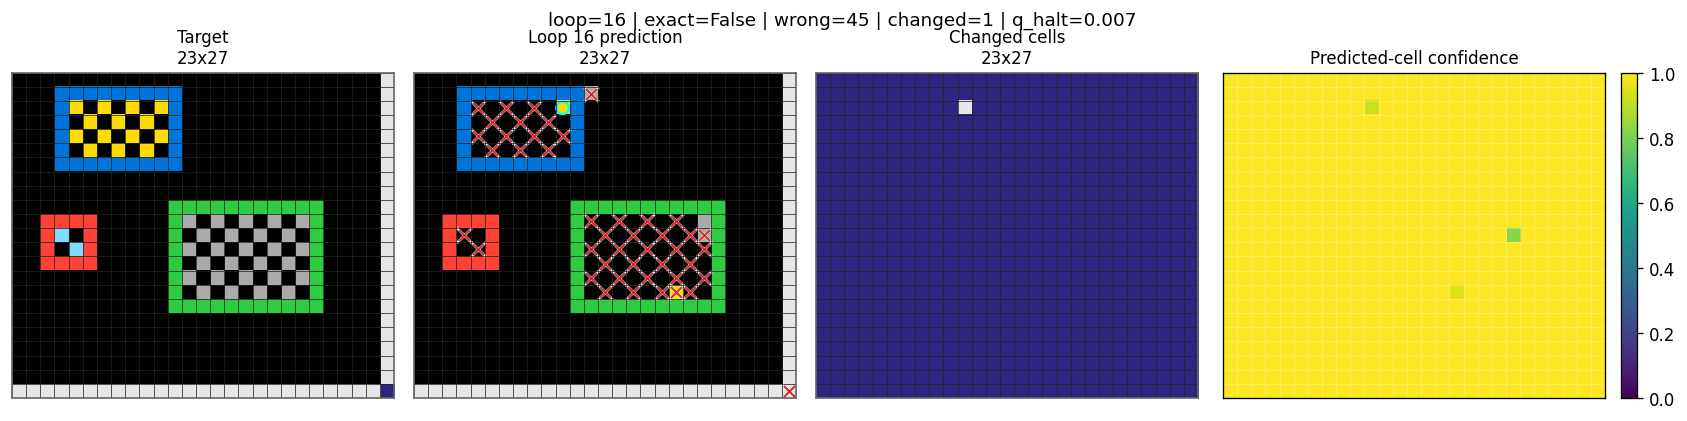

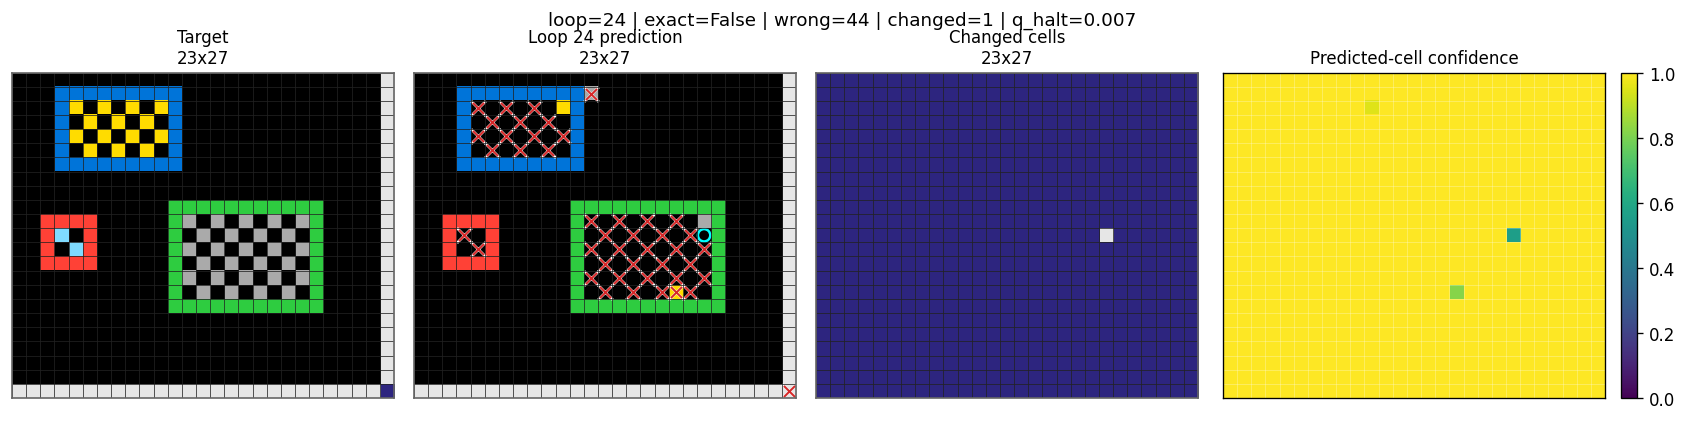

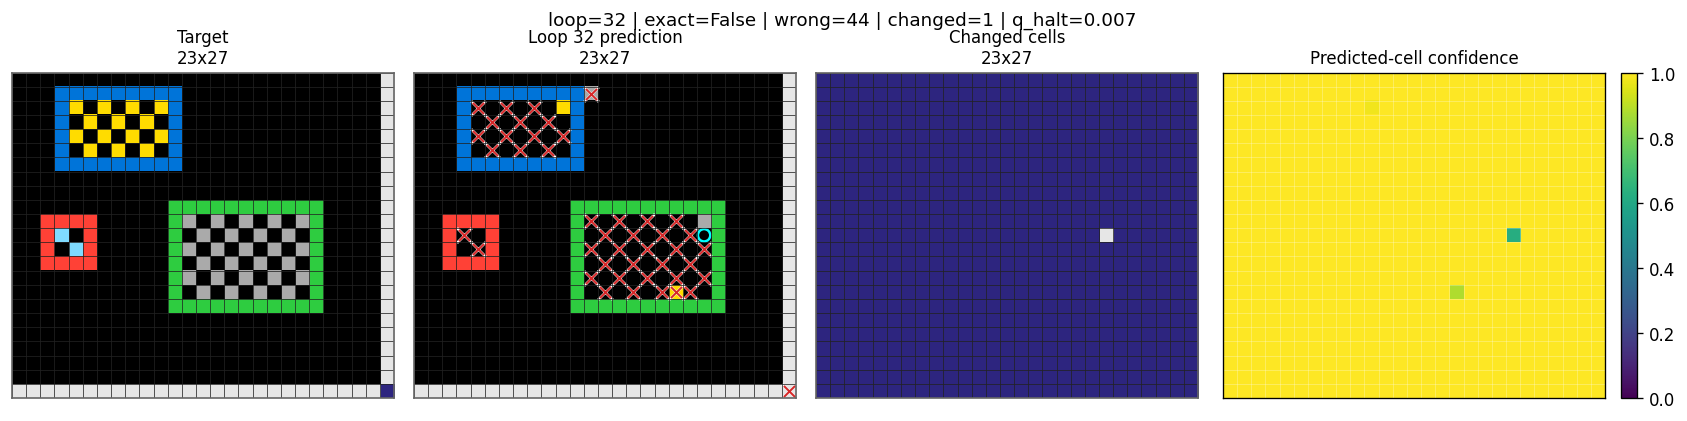

In [71]:
prompt_cols = len(batch_prompt_pairs)
fig, axes = plt.subplots(2, prompt_cols, figsize=(max(8.0, 2.1 * prompt_cols), 4.4), squeeze=False, constrained_layout=True)
context_idx = 0
for col, pair in enumerate(batch_prompt_pairs):
    if pair["is_query"]:
        title_prefix = "Query"
        output_title = "Query output slot"
    else:
        title_prefix = f"Context {context_idx}"
        output_title = f"Context {context_idx} output"
        context_idx += 1
    render_grid(axes[0, col], pair["input"], f"{title_prefix} input")
    render_grid(axes[1, col], pair["output"], output_title)
fig.suptitle(f"Input batch prompt | target_pair_id={batch_target_pair_id}", fontsize=12)
plt.show()

show_loops = [loop for loop in LOOPS_TO_SHOW if 1 <= loop <= len(decoded_trace)]
for loop in show_loops:
    item = decoded_trace[loop - 1]
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), constrained_layout=True)
    render_grid(axes[0], target_grid, "Target")
    render_grid(
        axes[1],
        item["pred_grid"],
        f"Loop {loop} prediction",
        wrong_mask=item["wrong_mask"],
        changed_mask=item["changed_mask"],
    )
    render_grid(axes[2], item["changed_mask"].astype(np.uint8), "Changed cells")
    im = render_confidence(axes[3], item["conf_grid"], "Predicted-cell confidence")
    fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
    fig.suptitle(
        f"loop={loop} | exact={not item['wrong_mask'].any()} | wrong={int(item['wrong_mask'].sum())} | "
        f"changed={int(item['changed_mask'].sum())} | q_halt={float(item['q_halt'][0]):.3f}",
        fontsize=11,
    )
    plt.show()

In [72]:
wrong_final = decoded_trace[-1]["wrong_mask"]
if wrong_final.any():
    print("Final wrong cells: row, col, target, pred, confidence, target_prob")
    final = decoded_trace[-1]
    for r, c in zip(*np.where(wrong_final)):
        print(
            f"({r:2d}, {c:2d}) target={int(target_grid[r, c])} pred={int(final['pred_grid'][r, c])} "
            f"conf={float(final['conf_grid'][r, c]):.3f} target_prob={float(final['true_prob_grid'][r, c]):.3f}"
        )
else:
    print("Final prediction is exact.")

Final wrong cells: row, col, target, pred, confidence, target_prob
( 1, 12) target=2 pred=7 conf=1.000 target_prob=0.000
( 2,  4) target=6 pred=2 conf=1.000 target_prob=0.000
( 2,  6) target=6 pred=2 conf=1.000 target_prob=0.000
( 2,  8) target=6 pred=2 conf=1.000 target_prob=0.000
( 3,  5) target=6 pred=2 conf=1.000 target_prob=0.000
( 3,  7) target=6 pred=2 conf=1.000 target_prob=0.000
( 3,  9) target=6 pred=2 conf=1.000 target_prob=0.000
( 4,  4) target=6 pred=2 conf=1.000 target_prob=0.000
( 4,  6) target=6 pred=2 conf=1.000 target_prob=0.000
( 4,  8) target=6 pred=2 conf=1.000 target_prob=0.000
( 4, 10) target=6 pred=2 conf=1.000 target_prob=0.000
( 5,  5) target=6 pred=2 conf=1.000 target_prob=0.000
( 5,  7) target=6 pred=2 conf=1.000 target_prob=0.000
( 5,  9) target=6 pred=2 conf=1.000 target_prob=0.000
(10, 12) target=7 pred=2 conf=1.000 target_prob=0.000
(10, 14) target=7 pred=2 conf=1.000 target_prob=0.000
(10, 16) target=7 pred=2 conf=1.000 target_prob=0.000
(10, 18) target